# Advanced Ride Demand Forecasting System

This notebook provides comprehensive exploratory data analysis (EDA) and interactive visualizations for our ride demand forecasting system. It serves as a complementary tool to the main runner script, offering insights into the data, model performance, and surge pricing optimization.



<a id='setup'></a>
## 1. Setup and Configuration

Let's start by importing the necessary libraries and setting up our environment.

In [59]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta
from pathlib import Path
from IPython.display import display, HTML
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set up matplotlib and seaborn styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Configure pandas display
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 3)

# Add project root to path
root_dir = Path().resolve()
src_dir = root_dir / 'src'
sys.path.append(str(root_dir))
sys.path.append(str(src_dir))

print(f'Project root: {root_dir}')
print(f'Source directory: {src_dir}')


Project root: D:\PROJECTS\DataScientistCaseStudy
Source directory: D:\PROJECTS\DataScientistCaseStudy\src


In [3]:
print(df['year'].value_counts())

year
-25    34136
Name: count, dtype: int64


In [47]:
df = pd.read_parquet('data/processed/enriched_trips.parquet')
print(df.info())
print(df.columns.to_list())
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34136 entries, 0 to 34135
Columns: 284 entries, start_location_id to wind_x_trip_dist_bin_long
dtypes: datetime64[ns](1), float32(234), int8(49)
memory usage: 32.3 MB
None
['start_location_id', 'hour_start', 'trip_count', 'hour', 'day', 'day_of_week', 'is_weekend', 'month', 'year', 'week_of_year', 'day_of_month', 'quarter', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos', 'month_sin', 'month_cos', 'is_rush_hour', 'is_night', 'is_holiday', 'holiday_proximity', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_diff_1_2h', 'lag_diff_2_3h', 'lag_diff_3_6h', 'lag_diff_6_12h', 'lag_diff_12_24h', 'lag_diff_24_48h', 'lag_diff_48_168h', 'rolling_3h_mean', 'rolling_3h_std', 'rolling_3h_max', 'rolling_3h_min', 'ewm_mean_alpha0.3_3h', 'ewm_mean_alpha0.3', 'ewm_mean_alpha0.5_3h', 'ewm_mean_alpha0.5', 'ewm_mean_alpha0.7_3h', 'ewm_mean_alpha0.7', 'ewm_mean_alp

,start_location_id,hour_start,trip_count,hour,day,day_of_week,is_weekend,month,year,week_of_year,day_of_month,quarter,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,month_sin,month_cos,is_rush_hour,is_night,is_holiday,holiday_proximity,lag_1h,lag_2h,lag_3h,lag_6h,lag_12h,lag_24h,lag_48h,lag_168h,lag_diff_1_2h,lag_diff_2_3h,lag_diff_3_6h,lag_diff_6_12h,lag_diff_12_24h,lag_diff_24_48h,lag_diff_48_168h,rolling_3h_mean,rolling_3h_std,rolling_3h_max,rolling_3h_min,ewm_mean_alpha0.3_3h,ewm_mean_alpha0.3,ewm_mean_alpha0.5_3h,ewm_mean_alpha0.5,ewm_mean_alpha0.7_3h,ewm_mean_alpha0.7,ewm_mean_alpha1.0_3h,...,prcp_lag3,prcp_lag6,temp_lag1,temp_lag3,temp_lag6,wspd_lag3,wspd_lag6,rhum_lag1,rhum_lag3,rhum_lag6,coco_lag1,coco_lag3,coco_lag6,heat_index,wind_chill,temp_anomaly24h,is_raining,is_heavy_rain,is_snowing,is_severe_weather,is_heatwave,is_freezing,is_high_wind,trip_dist_bin_short,trip_dist_bin_medium,trip_dist_bin_long,dest_cluster,dest_cluster_0,dest_cluster_1,rain_x_location_cluster_0,rain_x_location_cluster_1,temp_x_location_cluster_0,temp_x_location_cluster_1,wind_x_location_cluster_0,wind_x_location_cluster_1,rain_x_dest_cluster_0,rain_x_dest_cluster_1,temp_x_dest_cluster_0,temp_x_dest_cluster_1,wind_x_dest_cluster_0,wind_x_dest_cluster_1,rain_x_trip_dist_bin_short,rain_x_trip_dist_bin_medium,rain_x_trip_dist_bin_long,temp_x_trip_dist_bin_short,temp_x_trip_dist_bin_medium,temp_x_trip_dist_bin_long,wind_x_trip_dist_bin_short,wind_x_trip_dist_bin_medium,wind_x_trip_dist_bin_long
0,1,2023-05-31 23:00:00,2,23,31,2,0,5,-25,22,31,2,0.0,0.966,0.975,0.0,0.0,1.0,0.5,0.0,0,0,0,0,4.0,3.0,12.0,9.0,4.0,3.0,10.0,7.0,1.0,0.0,3.0,5.0,1.0,0.0,3.0,3.000,1.000,4.0,2.0,5.260,5.260,3.676,3.676,2.721,2.721,2.0,...,0.0,0.0,21.0,23.0,26.0,16.6,22.3,64.0,53.0,42.0,2.0,2.0,2.0,19.831,20.0,0.0,0,0,0,0,1,0,0,0,0,1,0,1,0,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,18.4
1,2,2023-05-31 23:00:00,3,23,31,2,0,5,-25,22,31,2,0.0,0.966,0.975,0.0,0.0,1.0,0.5,0.0,0,0,0,0,1.0,2.0,5.0,14.0,7.0,1.0,8.0,4.0,0.0,0.0,0.0,7.0,6.0,0.0,4.0,2.000,1.000,3.0,1.0,3.939,3.939,2.837,2.837,2.594,2.594,3.0,...,0.0,0.0,21.0,23.0,26.0,16.6,22.3,64.0,53.0,42.0,2.0,2.0,2.0,19.831,20.0,0.0,0,0,0,0,1,0,0,0,1,0,1,0,1,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,0.0,20.0,0.0,0.0,18.4,0.0
2,3,2023-05-31 23:00:00,6,23,31,2,0,5,-25,22,31,2,0.0,0.966,0.975,0.0,0.0,1.0,0.5,0.0,0,0,0,0,2.0,4.0,12.0,14.0,6.0,1.0,3.0,11.0,0.0,0.0,0.0,8.0,5.0,0.0,0.0,4.000,2.000,6.0,2.0,6.275,6.275,5.359,5.359,5.180,5.180,6.0,...,0.0,0.0,21.0,23.0,26.0,16.6,22.3,64.0,53.0,42.0,2.0,2.0,2.0,19.831,20.0,0.0,0,0,0,0,1,0,0,0,1,0,1,0,1,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,0.0,20.0,0.0,0.0,18.4,0.0
3,5,2023-05-31 23:00:00,2,23,31,2,0,5,-25,22,31,2,0.0,0.966,0.975,0.0,0.0,1.0,0.5,0.0,0,0,0,0,1.0,1.0,14.0,9.0,9.0,2.0,2.0,4.0,0.0,0.0,5.0,0.0,7.0,0.0,0.0,1.333,0.577,2.0,1.0,4.532,4.532,2.807,2.807,2.008,2.008,2.0,...,0.0,0.0,21.0,23.0,26.0,16.6,22.3,64.0,53.0,42.0,2.0,2.0,2.0,19.831,20.0,0.0,0,0,0,0,1,0,0,0,1,0,1,0,1,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,0.0,20.0,0.0,0.0,18.4,0.0
4,6,2023-05-31 23:00:00,4,23,31,2,0,5,-25,22,31,2,0.0,0.966,0.975,0.0,0.0,1.0,0.5,0.0,0,0,0,0,1.0,2.0,7.0,8.0,2.0,4.0,2.0,8.0,0.0,0.0,0.0,6.0,0.0,2.0,0.0,2.333,1.528,4.0,1.0,4.153,4.153,3.388,3.388,3.324,3.324,4.0,...,0.0,0.0,21.0,23.0,26.0,16.6,22.3,64.0,53.0,42.0,2.0,2.0,2.0,19.831,20.0,0.0,0,0,0,0,1,0,0,0,1,0,0,1,0,0.0,0.0,0.0,20.0,0.0,18.4,0.0,0.0,20.0,0.0,18.4,0.0,0.0,0.0,0.0,0.0,20.0,0.0,0.0,18.4,0.0


In [ ]:

df = pd.read_parquet("data/processed/prepared_trips.parquet")
wx = (df.sort_values(["start_location_id", "hour_start"])
        .drop_duplicates(subset=["start_location_id", "hour_start"])
        .reset_index(drop=True))     

wx["anan "]
a = df.merge(
            wx[["start_location_id", "hour_start"] + ["anan"]],
            on=["start_location_id", "hour_start"],
            how="left",
            validate="many_to_one"
        )
print(a.info())
a.head()

index   trip_id  passenger_id  driver_id  start_time           end_time                    start_location_id  end_location_id  distance_km  duration_min  price  surge_multiplier  register_location_id  signup_date  signup_date_passenger  registered_location_id  total_trips  user_next_trip_days  user_using_time  user_using_frequency  driver_next_trip_location  driver_next_trip_days  driver_trip_count  driver_work_time  driver_trip_frequency  regain_potential  hour_start           trip_count  hour  day  day_of_week  is_weekend  month  week_of_year  anan
199083  T199084  P04091        D0389      2023-05-31 23:28:00  2023-05-31 23:37:21.998461  10                 2                3.50         9.37          17.37  1.0               1                     2022-01-27   2022-03-03             7                       44           0.025                10919.467        6.525                 2                          0.012                  400                11759.917         14.237                

,index,trip_id,passenger_id,driver_id,start_time,end_time,start_location_id,end_location_id,distance_km,duration_min,price,surge_multiplier,register_location_id,signup_date,signup_date_passenger,registered_location_id,total_trips,user_next_trip_days,user_using_time,user_using_frequency,driver_next_trip_location,driver_next_trip_days,driver_trip_count,driver_work_time,driver_trip_frequency,regain_potential,hour_start,trip_count,hour,day,day_of_week,is_weekend,month,week_of_year,anan
0,0,T1,P00467,D0215,2023-01-01 00:52:00,2023-01-01 01:10:19.011076,1,8,3.11,18.32,17.99,1.0,7,2022-09-22,2022-09-11,4,45,3.870,6081.717,6.335,10,0.158,423,6041.133,13.586,3.845,2023-01-01 00:00:00,4,0,1,6,1,1,52,1
1,17,T18,P03000,D0081,2023-01-01 01:01:00,2023-01-01 01:08:46.894927,1,1,1.97,7.78,12.47,1.0,7,2022-08-26,2021-11-16,10,54,3.383,13362.550,7.266,9,0.847,414,6680.050,13.642,3.901,2023-01-01 01:00:00,1,1,1,6,1,1,52,1
2,37,T38,P04365,D0370,2023-01-01 02:29:00,2023-01-01 02:43:04.486670,1,10,2.41,14.07,15.04,1.0,3,2022-07-08,2021-06-07,4,42,3.255,17317.750,6.569,4,0.106,444,7866.950,14.099,3.820,2023-01-01 02:00:00,2,2,1,6,1,1,52,1
3,57,T58,P00824,D0417,2023-01-01 03:52:00,2023-01-01 04:04:21.329521,1,6,2.56,12.36,15.15,1.0,6,2022-09-19,2021-01-12,7,52,6.234,20866.400,7.350,2,0.139,402,6112.300,13.427,3.860,2023-01-01 03:00:00,1,3,1,6,1,1,52,1
4,80,T81,P02473,D0101,2023-01-01 04:51:00,2023-01-01 05:06:42.282611,1,6,4.03,15.70,20.23,1.0,3,2022-04-27,2022-07-15,4,48,1.438,7626.333,6.631,3,0.199,396,9587.433,13.945,3.951,2023-01-01 04:00:00,3,4,1,6,1,1,52,1


In [48]:
# show the column datetime type
print(df.select_dtypes(include=['datetime']).columns.to_list())
# show the column numeric type
print(df.select_dtypes(include=['number']).columns.to_list())
# show the column boolean type
print(df.select_dtypes(include=['bool']).columns.to_list())
# show the column category type
print(df.select_dtypes(include=['category']).columns.to_list())


['hour_start']
['start_location_id', 'trip_count', 'hour', 'day', 'day_of_week', 'is_weekend', 'month', 'year', 'week_of_year', 'day_of_month', 'quarter', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'day_of_month_sin', 'day_of_month_cos', 'month_sin', 'month_cos', 'is_rush_hour', 'is_night', 'is_holiday', 'holiday_proximity', 'lag_1h', 'lag_2h', 'lag_3h', 'lag_6h', 'lag_12h', 'lag_24h', 'lag_48h', 'lag_168h', 'lag_diff_1_2h', 'lag_diff_2_3h', 'lag_diff_3_6h', 'lag_diff_6_12h', 'lag_diff_12_24h', 'lag_diff_24_48h', 'lag_diff_48_168h', 'rolling_3h_mean', 'rolling_3h_std', 'rolling_3h_max', 'rolling_3h_min', 'ewm_mean_alpha0.3_3h', 'ewm_mean_alpha0.3', 'ewm_mean_alpha0.5_3h', 'ewm_mean_alpha0.5', 'ewm_mean_alpha0.7_3h', 'ewm_mean_alpha0.7', 'ewm_mean_alpha1.0_3h', 'ewm_mean_alpha1.0', 'rolling_6h_mean', 'rolling_6h_std', 'rolling_6h_max', 'rolling_6h_min', 'ewm_mean_alpha0.3_6h', 'ewm_mean_alpha0.5_6h', 'ewm_mean_alpha0.7_6h', 'ewm_mean_alpha1.0_6h', 'rolling_12h_mean', 

In [61]:
from src.utils.config_manager import ConfigManager

config_manager = ConfigManager('config.yaml')
config_manager.load()
config_manager.update_config('features.temporal_features', ['hour', 'day', 'day_of_week', 'is_weekend', 'month', 'year', 'week_of_year'])
config_manager.save()

AttributeError: 'ConfigManager' object has no attribute 'load'

In [49]:
df1 = pd.read_parquet('data/processed/prepared_trips.parquet')
print(df1.columns.to_list())

['index', 'trip_id', 'passenger_id', 'driver_id', 'start_time', 'end_time', 'start_location_id', 'end_location_id', 'distance_km', 'duration_min', 'price', 'surge_multiplier', 'register_location_id', 'signup_date', 'signup_date_passenger', 'registered_location_id', 'total_trips', 'user_next_trip_days', 'user_using_time', 'user_using_frequency', 'driver_next_trip_location', 'driver_next_trip_days', 'driver_trip_count', 'driver_work_time', 'driver_trip_frequency', 'regain_potential', 'hour_start', 'trip_count', 'hour', 'day', 'day_of_week', 'is_weekend', 'month', 'year', 'week_of_year']


In [27]:
def _context(df: pd.DataFrame) -> pd.DataFrame:
      cx = df.copy()
      agg_dict = {}
      win = [1, 3, 12, 24]
      # Passenger
      if {"user_using_frequency", "total_trips"}.issubset(cx.columns):
          cx["user_frequency_quartile"] = pd.qcut(cx["user_using_frequency"], 4,
                                                  labels=False, duplicates="drop")
          agg_dict.update({"user_frequency_quartile": "mean"})
          #self.context_features.update({"user_frequency_quartile"})

      # Driver
      if {"driver_trip_frequency", "driver_work_time"}.issubset(cx.columns):
          cx["driver_frequency_quartile"] = pd.qcut(cx["driver_trip_frequency"], 4,
                                                    labels=False, duplicates="drop")
          cx["driver_work_time_quartile"] = pd.qcut(cx["driver_work_time"], 4,
                                                    labels=False, duplicates="drop")
          agg_dict.update({"driver_frequency_quartile": "mean", "driver_work_time_quartile": "mean"})
          #self.context_features.update({"driver_frequency_quartile", "driver_work_time_quartile"})

      # Trip
      if {"price", "distance_km", "duration_min"}.issubset(cx.columns):
          cx["price_per_km"] = cx["price"] / cx["distance_km"].clip(lower=0.1)
          cx["price_per_min"] = cx["price"] / cx["duration_min"].clip(lower=0.1)
          cx["avg_speed_kmh"] = cx["distance_km"] / (cx["duration_min"] / 60).clip(lower=0.01)
          cx["trip_distance_quartile"] = pd.qcut(cx["distance_km"], 4,
                                                  labels=False, duplicates="drop")
          cx["trip_duration_quartile"] = pd.qcut(cx["duration_min"], 4,
                                                  labels=False, duplicates="drop")
          agg_dict.update({"price_per_km": "mean", "price_per_min": "mean", "avg_speed_kmh": "mean",
           "trip_distance_quartile": "mean", "trip_duration_quartile": "mean"})
      # Window features
      for w in win:
        win = f"{w}h"
        for col in agg_dict.keys():
          cx[f"lag_{col}_{win}_hour_{agg_dict[col]}"] = (
              cx.groupby("hour_start")[col].rolling(w).agg(agg_dict[col]).shift(1).reset_index(level="hour_start", drop=True))
          #self.context_features.add(f"lag_{col}_{win}_hour_{agg_dict[col]}")
      #merge
      df = pd.merge(df, cx, on=["hour_start", "start_location_id"], how="left")
      return df
prepared_trips = pd.read_parquet("data/processed/prepared_trips.parquet")
df = _context(prepared_trips)
print(df['lag_trip_distance_quartile_24h_hour_mean'].isnull().sum())
df.head()

519496


,index_x,start_time_x,trip_id_x,passenger_id_x,driver_id_x,end_time_x,start_location_id,end_location_id_x,distance_km_x,duration_min_x,price_x,surge_multiplier_x,register_location_id_x,signup_date_x,signup_date_passenger_x,registered_location_id_x,total_trips_x,user_next_trip_days_x,user_using_time_x,user_using_frequency_x,driver_next_trip_location_x,driver_next_trip_days_x,driver_trip_count_x,driver_work_time_x,driver_trip_frequency_x,regain_potential_x,hour_start,trip_count_x,hour_x,day_x,day_of_week_x,is_weekend_x,month_x,week_of_year_x,lag_driver_trip_frequency_1h_hour_mean_x,lag_driver_next_trip_location_1h_hour_mode_x,lag_driver_next_trip_days_1h_hour_mean_x,lag_user_using_frequency_1h_hour_mean_x,lag_user_next_trip_days_1h_hour_mean_x,lag_regain_potential_1h_hour_mean_x,lag_price_1h_hour_mean_x,lag_end_location_id_1h_hour_mode_x,lag_start_location_id_1h_hour_mode_x,lag_driver_trip_frequency_3h_hour_mean_x,lag_driver_next_trip_location_3h_hour_mode_x,lag_driver_next_trip_days_3h_hour_mean_x,lag_user_using_frequency_3h_hour_mean_x,lag_user_next_trip_days_3h_hour_mean_x,lag_regain_potential_3h_hour_mean_x,lag_price_3h_hour_mean_x,...,lag_start_location_id_12h_hour_mode_y,lag_driver_trip_frequency_24h_hour_mean_y,lag_driver_next_trip_location_24h_hour_mode_y,lag_driver_next_trip_days_24h_hour_mean_y,lag_user_using_frequency_24h_hour_mean_y,lag_user_next_trip_days_24h_hour_mean_y,lag_regain_potential_24h_hour_mean_y,lag_price_24h_hour_mean_y,lag_end_location_id_24h_hour_mode_y,lag_start_location_id_24h_hour_mode_y,user_frequency_quartile,driver_frequency_quartile,driver_work_time_quartile,price_per_km,price_per_min,avg_speed_kmh,trip_distance_quartile,trip_duration_quartile,lag_user_frequency_quartile_1h_hour_mean,lag_driver_frequency_quartile_1h_hour_mean,lag_driver_work_time_quartile_1h_hour_mean,lag_price_per_km_1h_hour_mean,lag_price_per_min_1h_hour_mean,lag_avg_speed_kmh_1h_hour_mean,lag_trip_distance_quartile_1h_hour_mean,lag_trip_duration_quartile_1h_hour_mean,lag_user_frequency_quartile_3h_hour_mean,lag_driver_frequency_quartile_3h_hour_mean,lag_driver_work_time_quartile_3h_hour_mean,lag_price_per_km_3h_hour_mean,lag_price_per_min_3h_hour_mean,lag_avg_speed_kmh_3h_hour_mean,lag_trip_distance_quartile_3h_hour_mean,lag_trip_duration_quartile_3h_hour_mean,lag_user_frequency_quartile_12h_hour_mean,lag_driver_frequency_quartile_12h_hour_mean,lag_driver_work_time_quartile_12h_hour_mean,lag_price_per_km_12h_hour_mean,lag_price_per_min_12h_hour_mean,lag_avg_speed_kmh_12h_hour_mean,lag_trip_distance_quartile_12h_hour_mean,lag_trip_duration_quartile_12h_hour_mean,lag_user_frequency_quartile_24h_hour_mean,lag_driver_frequency_quartile_24h_hour_mean,lag_driver_work_time_quartile_24h_hour_mean,lag_price_per_km_24h_hour_mean,lag_price_per_min_24h_hour_mean,lag_avg_speed_kmh_24h_hour_mean,lag_trip_distance_quartile_24h_hour_mean,lag_trip_duration_quartile_24h_hour_mean
0,0,2023-01-01 00:03:00,T4,P02889,D0167,2023-01-01 00:12:56.295441,1,2,2.58,9.94,14.73,1.0,2,2022-01-23,2022-08-14,6,42,0.754,6979.283,6.194,9,0.549,365,11847.000,13.909,3.865,2023-01-01,4,0,1,6,1,1,52,0.000,0.0,0.000,0.000,0.000,0.000,0.00,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.00,...,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.000,0.0,0.0,1,2,3,5.709,1.482,15.573,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,2023-01-01 00:03:00,T4,P02889,D0167,2023-01-01 00:12:56.295441,1,2,2.58,9.94,14.73,1.0,2,2022-01-23,2022-08-14,6,42,0.754,6979.283,6.194,9,0.549,365,11847.000,13.909,3.865,2023-01-01,4,0,1,6,1,1,52,0.000,0.0,0.000,0.000,0.000,0.000,0.00,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000,0.00,...,1.0,13.506,9.0,0.480,5.988,7.205,3.907,13.780,2.0,1.0,2,1,1,17.236,0.669,2.329,0,2,1.0,2.0,1.0,8.358,1.291,9.271,0.0,0.0,0.667,1.333,1.333,6.299,1.836,19.605,1.667,0.333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,2023-01-01 00:03:00,T4,P02889,D0167,2023-01-01 00:12

In [21]:
prepared_trips = pd.read_parquet("data/processed/prepared_trips.parquet")
print(prepared_trips.shape)
if 'start_time' not in prepared_trips.columns:
    print("hour_start column not found")
    prepared_trips = prepared_trips.assign(hour_start=pd.to_datetime(prepared_trips["start_time"]).dt.floor("H"))
#sort trips by hour_start and location_id ascending keep the first row
prepared_trips = prepared_trips.sort_values(by=['hour_start', 'start_location_id'], ascending=[False, True]).drop_duplicates(subset=['hour_start', 'start_location_id'], keep='first').reset_index(drop=True)

print(prepared_trips.shape)
prepared_trips.head()



(199086, 70)
(34136, 70)


,index,start_time,trip_id,passenger_id,driver_id,end_time,start_location_id,end_location_id,distance_km,duration_min,price,surge_multiplier,register_location_id,signup_date,signup_date_passenger,registered_location_id,total_trips,user_next_trip_days,user_using_time,user_using_frequency,driver_next_trip_location,driver_next_trip_days,driver_trip_count,driver_work_time,driver_trip_frequency,regain_potential,hour_start,trip_count,hour,day,day_of_week,is_weekend,month,week_of_year,lag_driver_trip_frequency_1h_hour_mean,lag_driver_next_trip_location_1h_hour_mode,lag_driver_next_trip_days_1h_hour_mean,lag_user_using_frequency_1h_hour_mean,lag_user_next_trip_days_1h_hour_mean,lag_regain_potential_1h_hour_mean,lag_price_1h_hour_mean,lag_end_location_id_1h_hour_mode,lag_start_location_id_1h_hour_mode,lag_driver_trip_frequency_3h_hour_mean,lag_driver_next_trip_location_3h_hour_mode,lag_driver_next_trip_days_3h_hour_mean,lag_user_using_frequency_3h_hour_mean,lag_user_next_trip_days_3h_hour_mean,lag_regain_potential_3h_hour_mean,lag_price_3h_hour_mean,lag_end_location_id_3h_hour_mode,lag_start_location_id_3h_hour_mode,lag_driver_trip_frequency_12h_hour_mean,lag_driver_next_trip_location_12h_hour_mode,lag_driver_next_trip_days_12h_hour_mean,lag_user_using_frequency_12h_hour_mean,lag_user_next_trip_days_12h_hour_mean,lag_regain_potential_12h_hour_mean,lag_price_12h_hour_mean,lag_end_location_id_12h_hour_mode,lag_start_location_id_12h_hour_mode,lag_driver_trip_frequency_24h_hour_mean,lag_driver_next_trip_location_24h_hour_mode,lag_driver_next_trip_days_24h_hour_mean,lag_user_using_frequency_24h_hour_mean,lag_user_next_trip_days_24h_hour_mean,lag_regain_potential_24h_hour_mean,lag_price_24h_hour_mean,lag_end_location_id_24h_hour_mode,lag_start_location_id_24h_hour_mode
0,199066,2023-05-31 23:04:00,T199064,P02602,D0227,2023-05-31 23:25:57.851706,1,9,3.05,21.96,18.54,1.0,8,2022-07-13,2022-08-17,7,38,0.033,6911.067,5.900,0,0.033,374,7751.067,13.477,3.819,2023-05-31 23:00:00,2,23,31,2,0,5,22,13.372,0.0,0.041,6.503,0.041,3.810,13.053,4.0,6.0,13.372,0.0,0.041,6.503,0.041,3.810,13.053,4.0,6.0,13.372,0.0,0.041,6.503,0.041,3.810,13.053,4.0,6.0,13.372,0.0,0.041,6.503,0.041,3.810,13.053,4.0,6.0
1,199073,2023-05-31 23:30:00,T199068,P00611,D0093,2023-05-31 23:44:55.930126,2,1,2.33,14.93,14.98,1.0,2,2022-11-28,2021-06-21,7,42,0.020,17039.500,6.563,0,0.020,377,4439.500,12.804,3.788,2023-05-31 23:00:00,3,23,31,2,0,5,22,13.811,0.0,0.030,6.299,0.032,3.861,15.815,4.0,3.0,13.811,0.0,0.030,6.299,0.032,3.861,15.815,4.0,3.0,13.811,0.0,0.030,6.299,0.032,3.861,15.815,4.0,3.0,13.811,0.0,0.030,6.299,0.032,3.861,15.815,4.0,3.0
2,199067,2023-05-31 23:14:00,T199071,P03362,D0342,2023-05-31 23:29:10.154329,3,4,4.10,15.17,20.33,1.0,5,2022-04-07,2021-05-07,8,45,0.031,18119.233,6.810,0,0.031,382,10079.233,13.877,3.964,2023-05-31 23:00:00,6,23,31,2,0,5,22,13.398,0.0,0.039,6.353,0.039,3.812,14.425,4.0,1.0,13.398,0.0,0.039,6.353,0.039,3.812,14.425,4.0,1.0,13.398,0.0,0.039,6.353,0.039,3.812,14.425,4.0,1.0,13.398,0.0,0.039,6.353,0.039,3.812,14.425,4.0,1.0
3,199078,2023-05-31 23:44:00,T199076,P03859,D0219,2023-05-31 23:53:17.725899,5,10,2.26,9.30,13.64,1.0,7,2022-03-17,2021-10-27,5,33,0.014,13967.733,5.745,0,0.014,413,10583.733,14.221,3.840,2023-05-31 23:00:00,2,23,31,2,0,5,22,13.757,0.0,0.027,6.270,0.028,3.855,15.775,4.0,3.0,13.757,0.0,0.027,6.270,0.028,3.855,15.775,4.0,3.0,13.757,0.0,0.027,6.270,0.028,3.855,15.775,4.0,3.0,13.757,0.0,0.027,6.270,0.028,3.855,15.775,4.0,3.0
4,199065,2023-05-31 23:02:00,T199077,P00990,D0256,2023-05-31 23:16:06.887190,6,4,1.38,14.11,11.96,1.0,5,2022-11-26,2021-01-24,6,49,0.040,20591.033,7.145,0,0.040,411,4487.033,13.101,3.766,2023-05-31 23:00:00,4,23,31,2,0,5,22,13.295,0.0,0.045,6.285,0.045,3.859,10.860,4.0,9.0,13.295,0.0,0.045,6.285,0.045,3.859,10.860,4.0,9.0,13.295,0.0,0.045,6.285,0.045,3.859,10.860,4.0,9.0,13.295,0.0,0.045,6.285,0.045,3.859,10.860,4.0,9.0


In [ ]:
#sort trips by start_time and location_id
trips = trips.groupby(['hour', 'start_location_id']).apply(lambda x: x.sort_values('start_time')).reset_index(drop=True)

trips.head()




,index,start_time,trip_id,passenger_id,driver_id,end_time,start_location_id,end_location_id,distance_km,duration_min,price,surge_multiplier,register_location_id,vehicle_type,signup_date,signup_date_passenger,registered_location_id,total_trips,user_using_time,user_using_frequency,user_next_trip_days,driver_next_trip_location,driver_trip_count,driver_work_time,driver_trip_frequency,regain_potential,hour_start,driver_work_time_mean,driver_trip_frequency_mean,vehicle_type_mode,register_location_id_mode,driver_next_trip_location_mode,total_trips_mean,user_using_frequency_mean,user_next_trip_days_mean,registered_location_id_mode,regain_potential_mean,to_loc_cnt_1h,to_loc_dist_1h,to_loc_dur_1h,to_loc_rp_1h,lag_top_location_from_1h,lag_top_location_to_1h,lag_avg_regain_potential_1h,to_loc_cnt_3h,to_loc_dist_3h,to_loc_dur_3h,to_loc_rp_3h,lag_top_location_from_3h,lag_top_location_to_3h,...,temp_x_hour_1,temp_x_hour_2,temp_x_hour_3,temp_x_hour_4,temp_x_hour_5,temp_x_hour_6,temp_x_hour_7,temp_x_hour_8,temp_x_hour_9,temp_x_hour_10,temp_x_hour_11,temp_x_hour_12,temp_x_hour_13,temp_x_hour_14,temp_x_hour_15,temp_x_hour_16,temp_x_hour_17,temp_x_hour_18,temp_x_hour_19,temp_x_hour_20,temp_x_hour_21,temp_x_hour_22,temp_x_hour_23,wind_x_hour_start,wind_x_hour_sin,wind_x_hour_cos,wind_x_hour_0,wind_x_hour_1,wind_x_hour_2,wind_x_hour_3,wind_x_hour_4,wind_x_hour_5,wind_x_hour_6,wind_x_hour_7,wind_x_hour_8,wind_x_hour_9,wind_x_hour_10,wind_x_hour_11,wind_x_hour_12,wind_x_hour_13,wind_x_hour_14,wind_x_hour_15,wind_x_hour_16,wind_x_hour_17,wind_x_hour_18,wind_x_hour_19,wind_x_hour_20,wind_x_hour_21,wind_x_hour_22,wind_x_hour_23
0,0,2023-01-01 00:03:00,T4,P02889,D0167,2023-01-01 00:12:56.295441,1,2,2.58,9.94,14.73,1.0,2,standard,2022-01-23,2022-08-14,6,42,6979.283,16.812,0.754,9,365,11847.000,146.805,81.660,2023-01-01,8775.017,156.653,standard,2,10,44.0,17.657,2.548,4,81.783,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.021e+18,0.0,3.6,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,3,2023-01-01 00:21:00,T2,P01185,D0460,2023-01-01 00:35:10.214410,1,10,0.55,14.17,9.48,1.0,3,standard,2022-08-25,2021-09-12,7,42,15019.833,16.926,1.283,10,401,6707.717,160.455,84.058,2023-01-01,8775.017,156.653,standard,2,10,44.0,17.657,2.548,4,81.783,0.0,0.0,0.0,0.0,1.0,2.0,81.660,0.0,0.0,0.0,0.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.021e+18,0.0,3.6,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10,2023-01-01 00:43:00,T3,P02048,D0476,2023-01-01 01:05:14.277127,1,3,2.82,22.24,17.91,1.0,8,standard,2022-03-20,2022-01-26,8,47,11779.367,18.903,4.287,4,374,10504.217,150.269,79.235,2023-01-01,8775.017,156.653,standard,2,10,44.0,17.657,2.548,4,81.783,0.0,0.0,0.0,0.0,1.0,2.0,82.859,0.0,0.0,0.0,0.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.021e+18,0.0,3.6,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,15,2023-01-01 00:52:00,T1,P00467,D0215,2023-01-01 01:10:19.011076,1,8,3.11,18.32,17.99,1.0,7,standard,2022-09-22,2022-09-11,4,45,6081.717,17.989,3.870,10,423,6041.133,169.085,82.180,2023-01-01,8775.017,156.653,standard,2,10,44.0,17.657,2.548,4,81.783,0.0,0.0,0.0,0.0,1.0,2.0,81.651,0.0,0.0,0.0,0.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.021e+18,0.0,3.6,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1372,2023-01-02 00:12:00,T1372,P02952,D0170,2023-01-02 00:24:55.395740,1,10,1.59,12.92,12.35,1.0,8,standard,2022-06-23,2021-06-29,9,40,16754.817,16.134,0.196,1,384,8226.300,153.949,73.550,2023-01-02,9209.871,159.699,standard,1,1,40.0,16.080,4.212,5,78.773,0.0,0.0,0.0,0.0,1.0,6.0,76.085,0.0,0.0,0.0,

In [ ]:
trips['trip_count'] = trips.groupby(['start_location_id', 'hour_start'])['trip_id'].transform('count')

In [ ]:
trips

,trip_id,passenger_id,driver_id,start_time,end_time,start_location_id,end_location_id,distance_km,duration_min,price,surge_multiplier,hour_start,trip_count
0,T1,P00467,D0215,2023-01-01 00:52:00,2023-01-01 01:10:19.011076,1,8,3.11,18.32,17.99,1.0,2023-01-01 00:00:00,4
1,T2,P01185,D0460,2023-01-01 00:21:00,2023-01-01 00:35:10.214410,1,10,0.55,14.17,9.48,1.0,2023-01-01 00:00:00,4
2,T3,P02048,D0476,2023-01-01 00:43:00,2023-01-01 01:05:14.277127,1,3,2.82,22.24,17.91,1.0,2023-01-01 00:00:00,4
3,T4,P02889,D0167,2023-01-01 00:03:00,2023-01-01 00:12:56.295441,1,2,2.58,9.94,14.73,1.0,2023-01-01 00:00:00,4
4,T5,P01364,D0092,2023-01-01 00:43:00,2023-01-01 00:52:51.924287,2,7,2.50,9.87,14.47,1.0,2023-01-01 00:00:00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199081,T199082,P03385,D0045,2023-05-31 23:47:00,2023-05-31 23:59:06.021843,8,2,1.96,12.10,13.30,1.0,2023-05-31 23:00:00,1
199082,T199083,P01153,D0061,2023-05-31 23:01:00,2023-05-31 23:08:31.596505,9,4,1.45,7.53,10.86,1.0,2023-05-31 23:00:00,1
199083,T199084,P04091,D0389,2023-05-31 23:28:00,2023-05-31 23:37:21.998461,10,2,3.50,9.37,17.37,1.0,2023-05-31 23:00:00,3
199084,T199085,P04269,D0130,2023-05-31 23:49:00,2023-05-31 23:59:44.653274,10,9,3.02,10.74,16.21,1.0,2023-05-31 23:00:00,3


In [ ]:
hourly_demand

,start_location_id,hour_start,trip_count
0,1,2023-01-01 00:00:00,4.0
1,1,2023-01-01 01:00:00,1.0
2,1,2023-01-01 02:00:00,2.0
3,1,2023-01-01 03:00:00,1.0
4,1,2023-01-01 04:00:00,3.0
...,...,...,...
36235,8,2023-05-31 19:00:00,5.0
36236,8,2023-05-31 20:00:00,9.0
36237,8,2023-05-31 21:00:00,2.0
36238,8,2023-05-31 22:00:00,1.0


In [ ]:
# Import project modules
from src.utils.logger import StructuredLogger
from src.utils.config_manager import ConfigManager
from src.data.data_loader import DataLoader
from src.features.feature_engineer import FeatureEngineer
from src.models.model_factory import ModelFactory
from src.evaluation.model_evaluator import ModelEvaluator
from src.evaluation.visualization import ForecastVisualizer
from src.evaluation.price_evaluator import PriceEvaluator
from src.pricing.surge_optimizer import SurgePricingOptimizer

# Load configuration
config_path = root_dir / 'config.yaml'
config = ConfigManager(config_path)

# Initialize logger for the notebook
logger = StructuredLogger('notebook', console_level='INFO')

print(f'Configuration loaded from {config_path}')

Configuration loaded from D:\PROJECTS\DataScientistCaseStudy\config.yaml


<a id='data-exploration'></a>
## 2. Data Loading and Exploration

In this section, we'll load the ride data and perform comprehensive exploratory data analysis to understand the patterns and characteristics of ride demand.

In [ ]:
# Initialize data loader
data_loader = DataLoader(config, logger)

# Check if processed data exists, otherwise load from raw data
try:
    print('Attempting to load preprocessed data...')
    hourly_demand = data_loader.load_processed_data('hourly_demand.parquet')
    print(f'Loaded preprocessed hourly demand data: {len(hourly_demand)} records')
except FileNotFoundError:
    print('Preprocessed data not found, loading from raw data...')
    # Check if raw data exists
    raw_path = config.get_full_path(config.get('data.raw_path', 'data/raw'))
    trips_file = raw_path / 'trips.parquet'
    
    if not trips_file.exists():
        print('Raw data not found, generating synthetic data for demonstration...')
        # We'll generate synthetic data for demonstration purposes
        from src.data.synthetic_data_generator import generate_synthetic_data
        raw_path.mkdir(parents=True, exist_ok=True)
        generate_synthetic_data(output_dir=raw_path)
        print(f'Synthetic data generated at {raw_path}')
    
    # Load trips data
    data_loader.load_trips_data()
    
    # Aggregate to hourly demand
    hourly_demand = data_loader.aggregate_hourly_demand()
    
    # Save processed data
    processed_path = config.get_full_path(config.get('data.processed_path', 'data/processed'))
    processed_path.mkdir(parents=True, exist_ok=True)
    data_loader.save_processed_data('hourly_demand', 'hourly_demand.parquet')
    print(f'Aggregated hourly demand data saved: {len(hourly_demand)} records')

# Display a sample of the data
display(hourly_demand.head())


Attempting to load preprocessed data...
2025-05-10 22:33:15,537 - notebook - INFO - Starting operation: load_processed_data
2025-05-10 22:33:15,616 - notebook - INFO - Loaded hourly_demand from D:\PROJECTS\DataScientistCaseStudy\data\processed\hourly_demand.parquet: 36240 records
2025-05-10 22:33:15,617 - notebook - INFO - Completed operation: load_processed_data in 0.08s
Loaded preprocessed hourly demand data: 36240 records


,start_location_id,hour_start,trip_count,hour,day,day_of_week,is_weekend,month,week_of_year,demand
0,1,2023-01-01 00:00:00,4,0,1,6,1,1,52,4
1,1,2023-01-01 01:00:00,1,1,1,6,1,1,52,1
2,1,2023-01-01 02:00:00,2,2,1,6,1,1,52,2
3,1,2023-01-01 03:00:00,1,3,1,6,1,1,52,1
4,1,2023-01-01 04:00:00,3,4,1,6,1,1,52,3


In [ ]:
df_trips = data_loader.load_trips_data()
df_trips.head()
df_trips.info()

### 2.1 Basic Data Statistics

Let's examine the basic statistics of our demand data to understand its distribution and characteristics.

In [ ]:
# Display basic statistics
print('Basic statistics for hourly demand:')
display(hourly_demand.describe())

# Check for missing values
print('Missing values:')
missing_values = hourly_demand.isna().sum()
display(missing_values[missing_values > 0] if any(missing_values > 0) else 'No missing values')

# Check data types
print('Data types:')
display(hourly_demand.dtypes)

Basic statistics for hourly demand:


,start_location_id,hour_start,trip_count,hour,day,day_of_week,is_weekend,month,week_of_year,demand
count,36240.000,36240,36240.000,36240.000,36240.000,36240.000,36240.000,36240.000,36240.0,36240.000
mean,5.500,2023-03-17 11:30:00.000000256,5.494,11.500,15.623,2.980,0.285,3.013,11.49,5.494
min,1.000,2023-01-01 00:00:00,0.000,0.000,1.000,0.000,0.000,1.000,1.0,0.000
25%,3.000,2023-02-07 17:45:00,2.000,5.750,8.000,1.000,0.000,2.000,6.0,2.000
50%,5.500,2023-03-17 11:30:00,5.000,11.500,16.000,3.000,0.000,3.000,11.0,5.000
75%,8.000,2023-04-24 05:15:00,8.000,17.250,23.000,5.000,1.000,4.000,17.0,8.000
max,10.000,2023-05-31 23:00:00,21.000,23.000,31.000,6.000,1.000,5.000,52.0,21.000
std,2.872,NaN,3.783,6.922,8.751,2.011,0.451,1.424,6.999,3.783


Missing values:


'No missing values'

Data types:


start_location_id             int64
hour_start           datetime64[ns]
trip_count                    int64
hour                          int32
day                           int32
day_of_week                   int32
is_weekend                    int64
month                         int32
week_of_year                 UInt32
demand                        int64
dtype: object

### 2.2 Demand Distribution Analysis

Let's visualize the distribution of ride demand to understand its characteristics and identify any outliers.

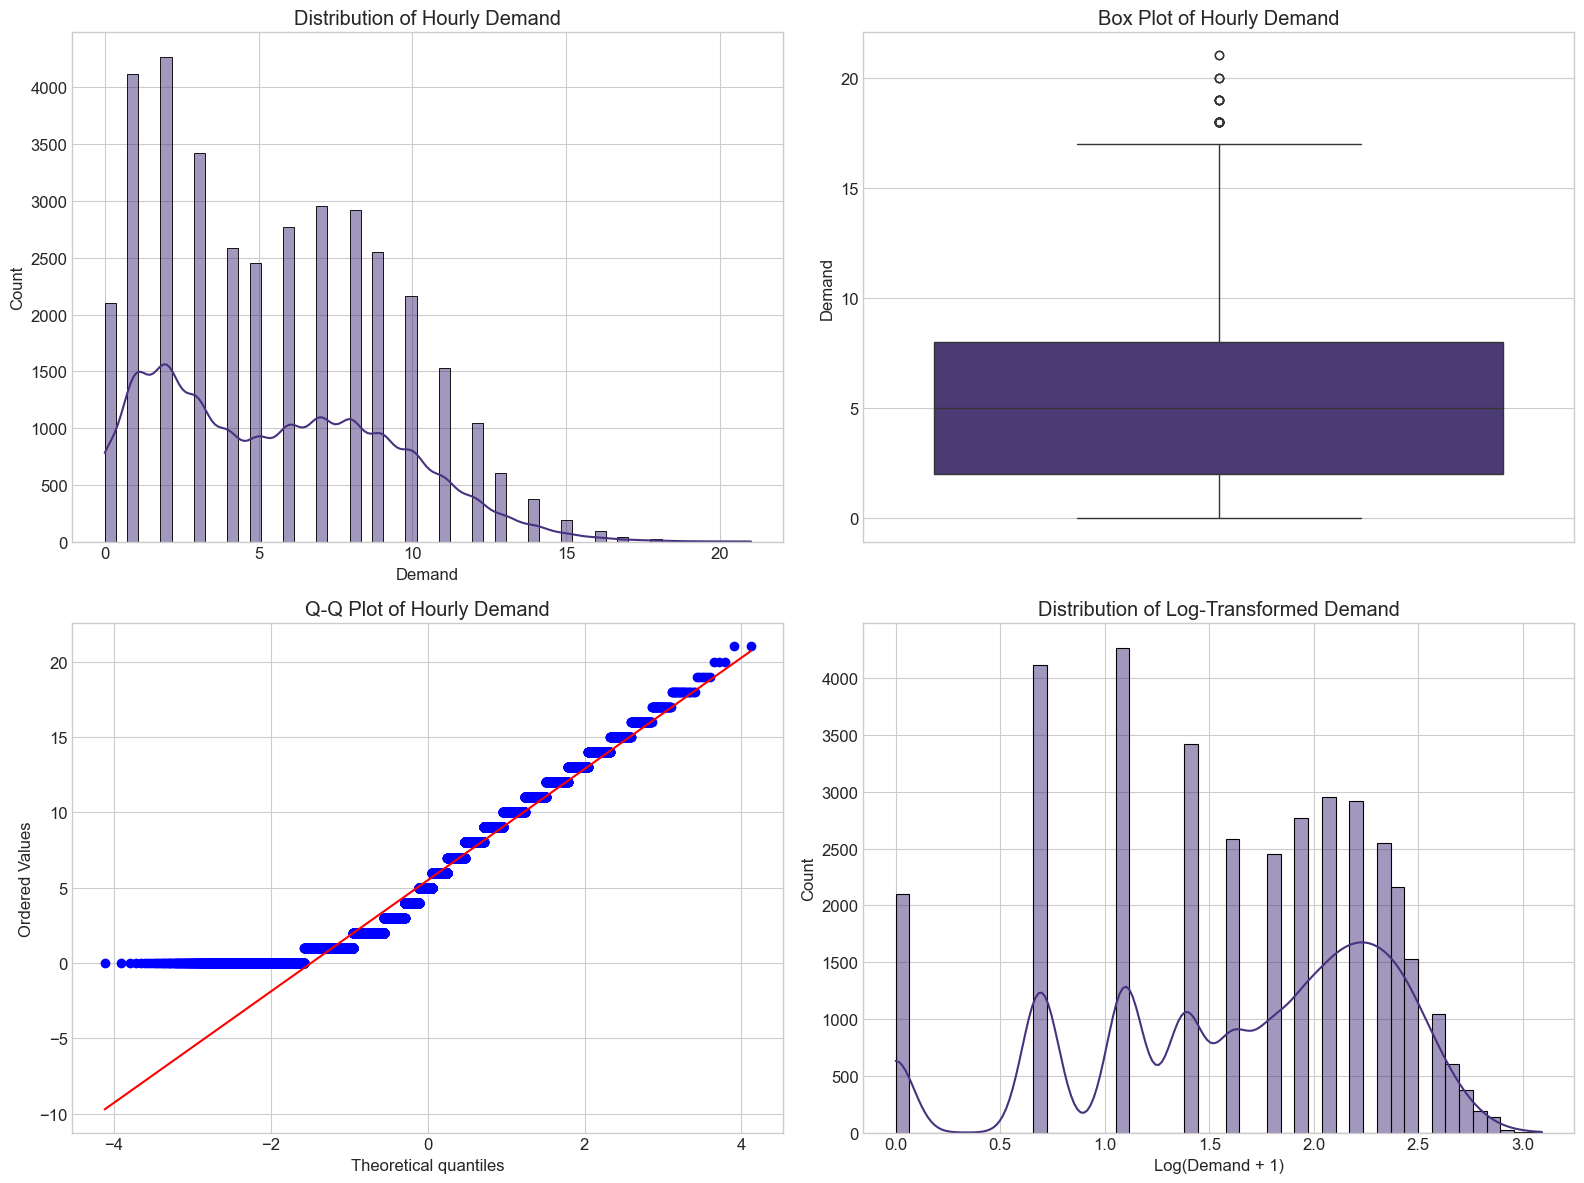

,Metric,Value
0,Mean,5.494
1,Median,5.000
2,Std Dev,3.783
3,Min,0.000
4,Max,21.000
5,Range,21.000
6,IQR,6.000
7,Skewness,0.430
8,Kurtosis,-0.651


In [ ]:
# Create a figure with multiple plots to analyze demand distribution
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Histogram of demand
sns.histplot(hourly_demand['demand'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Hourly Demand')
axes[0, 0].set_xlabel('Demand')

# Box plot of demand
sns.boxplot(y=hourly_demand['demand'], ax=axes[0, 1])
axes[0, 1].set_title('Box Plot of Hourly Demand')
axes[0, 1].set_ylabel('Demand')

# Q-Q plot to check normality
from scipy import stats
stats.probplot(hourly_demand['demand'], plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Hourly Demand')

# Log-transformed demand distribution
sns.histplot(np.log1p(hourly_demand['demand']), kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Log-Transformed Demand')
axes[1, 1].set_xlabel('Log(Demand + 1)')

plt.tight_layout()
plt.show()

# Compute and display summary statistics about the demand distribution
demand_stats = pd.DataFrame({
    'Metric': ['Mean', 'Median', 'Std Dev', 'Min', 'Max', 'Range', 'IQR', 'Skewness', 'Kurtosis'],
    'Value': [
        hourly_demand['demand'].mean(),
        hourly_demand['demand'].median(),
        hourly_demand['demand'].std(),
        hourly_demand['demand'].min(),
        hourly_demand['demand'].max(),
        hourly_demand['demand'].max() - hourly_demand['demand'].min(),
        hourly_demand['demand'].quantile(0.75) - hourly_demand['demand'].quantile(0.25),
        hourly_demand['demand'].skew(),
        hourly_demand['demand'].kurt()
    ]
})

display(demand_stats)

### 2.3 Temporal Patterns Analysis

Let's analyze how demand varies over different time periods (hour of day, day of week, etc.) to identify temporal patterns.

In [ ]:
# Ensure hour_start is datetime
if not pd.api.types.is_datetime64_any_dtype(hourly_demand['hour_start']):
    hourly_demand['hour_start'] = pd.to_datetime(hourly_demand['hour_start'])

# Extract time components
hourly_demand['hour'] = hourly_demand['hour_start'].dt.hour
hourly_demand['day_of_week'] = hourly_demand['hour_start'].dt.dayofweek
hourly_demand['day_name'] = hourly_demand['hour_start'].dt.day_name()
hourly_demand['date'] = hourly_demand['hour_start'].dt.date
hourly_demand['month'] = hourly_demand['hour_start'].dt.month
hourly_demand['week_of_year'] = hourly_demand['hour_start'].dt.isocalendar().week

# Time series plot of demand over the entire period
plt.figure(figsize=(16, 6))
plt.plot(hourly_demand['hour_start'], hourly_demand['demand'])
plt.title('Ride Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Hourly patterns
hourly_avg = hourly_demand.groupby('hour')['demand'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='hour', y='demand', data=hourly_avg, color='steelblue')
plt.title('Average Demand by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Demand')
plt.xticks(range(0, 24))
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Day of week patterns
day_avg = hourly_demand.groupby(['day_of_week', 'day_name'])['demand'].mean().reset_index()
day_avg = day_avg.sort_values('day_of_week')

plt.figure(figsize=(12, 6))
sns.barplot(x='day_name', y='demand', data=day_avg, color='steelblue')
plt.title('Average Demand by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Demand')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Heatmap of demand by hour and day of week
heatmap_data = hourly_demand.pivot_table(
    index='day_of_week', 
    columns='hour', 
    values='demand', 
    aggfunc='mean'
).round(1)

# Rename indices to day names
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data.index = day_names

plt.figure(figsize=(16, 8))
sns.heatmap(heatmap_data, cmap='viridis', annot=True, fmt='.1f', linewidths=.5)
plt.title('Average Demand by Hour and Day of Week')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()